# Profit Erosion Analysis - TheLook E-commerce EDA

This notebook analyzes **profit erosion driven by product returns** using the BigQuery Public Dataset `bigquery-public-data.thelook_ecommerce`.

## Analysis Focus
- **Margin reversal** on returned items (sale price - cost)
- **Profit erosion** from return processing costs
- **Customer and product segments** with high return exposure

## Notebook Structure

1. **Setup and Imports** - Load project modules from `src/`
2. **Test Data Processing Pipeline** - Validate each data processing function:
   - `load_raw_data()` - Load CSV files from BigQuery export
   - `merge_datasets()` - Merge into order-item grain
   - `engineer_return_features()` - Add return flags
   - `calculate_margins()` - Add margin calculations
   - `standardize_dtypes()` - Standardize column types
   - `build_analysis_dataset()` - Full pipeline with parquet output
3. **Data Loading** - Quality report and data preview
4. **EDA: Status Distribution** - Order item status breakdown
5. **EDA: Return Rate Analysis** - By category, brand, traffic source
6. **Margin-Focused EDA** - Margin exposure, lost sales, margin loss by category
7. **Profit Erosion Summary** - Total margin reversal + process costs
8. **Customer Segmentation** - Segment by return behavior
9. **Data Limitations** - Return timing data availability

## Prerequisites

Raw CSV files from BigQuery in `data/raw/`:
- `order_items.csv`
- `orders.csv`
- `products.csv`
- `users.csv`

## Project Modules Used

| Module | Functions |
|--------|-----------|
| `src.config` | `RAW_DATA_DIR`, `PROCESSED_DATA_DIR`, `PROCESSED_PARQUET` |
| `src.data_processing` | `load_raw_data`, `merge_datasets`, `engineer_return_features`, `calculate_margins`, `build_analysis_dataset`, `load_processed_data` |
| `src.visualization` | `plot_status_distribution`, `plot_return_rate_by_category`, `plot_margin_distribution`, `plot_margin_loss_by_category`, `plot_customer_margin_exposure` |
| `src.modeling` | `calculate_return_rates_by_group`, `calculate_margin_loss_by_group`, `summarize_profit_erosion`, `segment_customers_by_return_behavior` |

## Setup and Imports

In [1]:
# Standard imports
import sys
from pathlib import Path

# Add project root to path for src imports
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Project imports
from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, PROCESSED_PARQUET
from src.data_processing import (
    load_raw_data,
    merge_datasets,
    engineer_return_features,
    calculate_margins,
    standardize_dtypes,
    build_analysis_dataset,
    load_processed_data,
    get_data_quality_report,
)
from src.visualization import (
    set_plot_style,
    plot_status_distribution,
    plot_return_rate_by_category,
    plot_margin_distribution,
    plot_margin_loss_by_category,
    plot_customer_margin_exposure,
    plot_return_rate_heatmap,
)
from src.modeling import (
    calculate_return_rates_by_group,
    calculate_margin_loss_by_group,
    build_customer_behavior_profile,
    calculate_customer_margin_exposure,
    summarize_profit_erosion,
    segment_customers_by_return_behavior,
)

# Set plotting style
set_plot_style()

print(f"Project root: {project_root}")
print(f"Raw data dir: {RAW_DATA_DIR}")
print(f"Processed data dir: {PROCESSED_DATA_DIR}")

Project root: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project
Raw data dir: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project\data\raw
Processed data dir: c:\Users\folij077\OneDrive - GUSCanada\SCHOOL\Winter 2026\Capstone\bQuery_theLook\unfc-capstone-project\data\processed


## Test Data Processing Pipeline

Before loading the full dataset, let's verify the data processing functions work correctly by testing them on sample data.

In [2]:
# Test 1: Load raw data files
print("Testing load_raw_data()...")
order_items, orders, products, users = load_raw_data()
print(f"  order_items: {len(order_items):,} rows, {len(order_items.columns)} columns")
print(f"  orders: {len(orders):,} rows, {len(orders.columns)} columns")
print(f"  products: {len(products):,} rows, {len(products.columns)} columns")
print(f"  users: {len(users):,} rows, {len(users.columns)} columns")

Testing load_raw_data()...
  order_items: 180,908 rows, 11 columns
  orders: 124,903 rows, 9 columns
  products: 29,120 rows, 9 columns
  users: 100,000 rows, 16 columns


In [3]:
# Test 2: Merge datasets
print("Testing merge_datasets()...")
df_merged = merge_datasets(order_items, orders, products, users)
print(f"  Merged dataset: {len(df_merged):,} rows, {len(df_merged.columns)} columns")
print(f"  Sample columns: {df_merged.columns[:10].tolist()}")

Testing merge_datasets()...
  Merged dataset: 180,908 rows, 43 columns
  Sample columns: ['order_item_id', 'order_id', 'user_id', 'product_id', 'inventory_item_id', 'item_status', 'item_created_at', 'item_shipped_at', 'item_delivered_at', 'item_returned_at']


In [4]:
# Test 3: Engineer return features
print("Testing engineer_return_features()...")
df_with_returns = engineer_return_features(df_merged)
print(f"  Added columns: is_returned_item, is_returned_order")
print(f"  Return rate: {df_with_returns['is_returned_item'].mean() * 100:.2f}%")

Testing engineer_return_features()...
  Added columns: is_returned_item, is_returned_order
  Return rate: 10.06%


In [5]:
# Test 4: Calculate margins
print("Testing calculate_margins()...")
df_with_margins = calculate_margins(df_with_returns)
print(f"  Added columns: item_margin, item_margin_pct, discount_amount, discount_pct")
print(f"  Margin columns present: {[c for c in df_with_margins.columns if 'margin' in c.lower()]}")
print(f"  Sample margin stats:")
print(f"    Mean item_margin: ${df_with_margins['item_margin'].mean():.2f}")
print(f"    Median item_margin: ${df_with_margins['item_margin'].median():.2f}")

Testing calculate_margins()...
  Added columns: item_margin, item_margin_pct, discount_amount, discount_pct
  Margin columns present: ['item_margin', 'item_margin_pct']
  Sample margin stats:
    Mean item_margin: $31.04
    Median item_margin: $20.23


In [6]:
# Test 5: Standardize data types
print("Testing standardize_dtypes()...")
df_standardized = standardize_dtypes(df_with_margins)
print(f"  Final dataset: {len(df_standardized):,} rows, {len(df_standardized.columns)} columns")
print(f"  All columns: {df_standardized.columns.tolist()}")

Testing standardize_dtypes()...
  Final dataset: 180,908 rows, 49 columns
  All columns: ['order_item_id', 'order_id', 'user_id', 'product_id', 'inventory_item_id', 'item_status', 'item_created_at', 'item_shipped_at', 'item_delivered_at', 'item_returned_at', 'sale_price', 'order_status', 'order_created_at', 'order_shipped_at', 'order_delivered_at', 'order_returned_at', 'num_of_item', 'order_gender', 'product_dim_id', 'cost', 'category', 'name', 'brand', 'retail_price', 'department', 'sku', 'distribution_center_id', 'user_dim_id', 'first_name', 'last_name', 'email', 'age', 'user_gender', 'state', 'street_address', 'postal_code', 'city', 'country', 'latitude', 'longitude', 'traffic_source', 'user_created_at', 'user_geom', 'is_returned_item', 'is_returned_order', 'discount_amount', 'discount_pct', 'item_margin', 'item_margin_pct']


In [7]:
# Test 6: Build complete analysis dataset (saves to data/processed/)
print("Testing build_analysis_dataset()...")
print("This will rebuild and save the processed parquet file with all features.")
df = build_analysis_dataset(save_output=True)
print(f"\nDataset built and saved!")
print(f"  Rows: {len(df):,}")
print(f"  Columns: {len(df.columns)}")
print(f"  Margin columns: {[c for c in df.columns if 'margin' in c.lower()]}")
print(f"  Return columns: {[c for c in df.columns if 'return' in c.lower()]}")

Testing build_analysis_dataset()...
This will rebuild and save the processed parquet file with all features.

Dataset built and saved!
  Rows: 180,908
  Columns: 49
  Margin columns: ['item_margin', 'item_margin_pct']
  Return columns: ['item_returned_at', 'order_returned_at', 'is_returned_item', 'is_returned_order']


## Data Loading

Choose one of the following options:
1. **Build from raw files** - Use if you need to rebuild the dataset
2. **Load processed parquet** - Use for faster loading if data already exists

In [8]:
# Data is already loaded from build_analysis_dataset() above
# If you need to reload from the saved parquet file later:
# df = load_processed_data()

# Display data quality report
quality_report = get_data_quality_report(df)
print(f"Data Quality Report:")
print(f"  Total rows: {quality_report['total_rows']:,}")
print(f"  Unique order items: {quality_report['unique_order_items']:,}")
print(f"  Unique orders: {quality_report['unique_orders']:,}")
print(f"  Unique users: {quality_report['unique_users']:,}")
print(f"  Return rate: {quality_report['return_rate']:.2f}%")

Data Quality Report:
  Total rows: 180,908
  Unique order items: 180,908
  Unique orders: 124,903
  Unique users: 79,944
  Return rate: 10.06%


In [9]:
# Preview the data
df.head()

,order_item_id,order_id,user_id,product_id,inventory_item_id,item_status,item_created_at,item_shipped_at,item_delivered_at,item_returned_at,...,longitude,traffic_source,user_created_at,user_geom,is_returned_item,is_returned_order,discount_amount,discount_pct,item_margin,item_margin_pct
0,110641,76414,61335,14235,298798,Cancelled,2024-11-21 23:08:55+00:00,NaT,NaT,NaT,...,103.810039,Organic,2024-11-08 18:12:00+00:00,POINT(103.8100391 36.05410331),0,0,0.0,0.0,0.0117,0.585
1,7853,5466,4461,14235,21307,Complete,2025-06-23 17:19:15+00:00,2025-06-24 18:11:46+00:00,2025-06-26 01:55:46+00:00,NaT,...,112.727120,Organic,2025-05-23 11:47:00+00:00,POINT(112.7271198 38.44663152),0,0,0.0,0.0,0.0117,0.585
2,114425,79025,63450,14235,309053,Complete,2025-12-22 06:18:07+00:00,2025-12-25 00:54:06+00:00,2025-12-26 03:59:06+00:00,NaT,...,-3.685632,Search,2025-07-10 00:11:00+00:00,POINT(-3.685632436 40.24690462),0,0,0.0,0.0,0.0117,0.585
3,167396,115509,92500,14235,452082,Complete,2022-04-28 14:34:03+00:00,2022-04-25 13:35:52+00:00,2022-04-27 02:46:52+00:00,NaT,...,-50.775911,Search,2020-12-15 15:48:00+00:00,POINT(-50.77591148 -29.35123809),0,0,0.0,0.0,0.0117,0.585
4,9435,6560,5325,14235,25590,Processing,2022-07-23 04:49:36+00:00,NaT,NaT,NaT,...,121.649492,Search,2020-04-07 17:53:00+00:00,POINT(121.6494925 31.20926075),0,0,0.0,0.0,0.0117,0.585


In [10]:
# Check columns
print(f"Total columns: {len(df.columns)}")
df.columns.tolist()

Total columns: 49


['order_item_id',
 'order_id',
 'user_id',
 'product_id',
 'inventory_item_id',
 'item_status',
 'item_created_at',
 'item_shipped_at',
 'item_delivered_at',
 'item_returned_at',
 'sale_price',
 'order_status',
 'order_created_at',
 'order_shipped_at',
 'order_delivered_at',
 'order_returned_at',
 'num_of_item',
 'order_gender',
 'product_dim_id',
 'cost',
 'category',
 'name',
 'brand',
 'retail_price',
 'department',
 'sku',
 'distribution_center_id',
 'user_dim_id',
 'first_name',
 'last_name',
 'email',
 'age',
 'user_gender',
 'state',
 'street_address',
 'postal_code',
 'city',
 'country',
 'latitude',
 'longitude',
 'traffic_source',
 'user_created_at',
 'user_geom',
 'is_returned_item',
 'is_returned_order',
 'discount_amount',
 'discount_pct',
 'item_margin',
 'item_margin_pct']

## EDA: Order Item Status Distribution

In [11]:
# Item status distribution using pandas
status_dist = (
    df.groupby("item_status")
      .agg(
          order_item_rows=("order_item_id", "size"),
          orders=("order_id", "nunique"),
          users=("user_id", "nunique")
      )
      .sort_values("order_item_rows", ascending=False)
)
status_dist

,order_item_rows,orders,users
item_status,,,
Shipped,53931,37333,32119
Complete,45277,31229,27557
Processing,36215,24919,22448
Cancelled,27277,18821,17471
Returned,18208,12601,11988


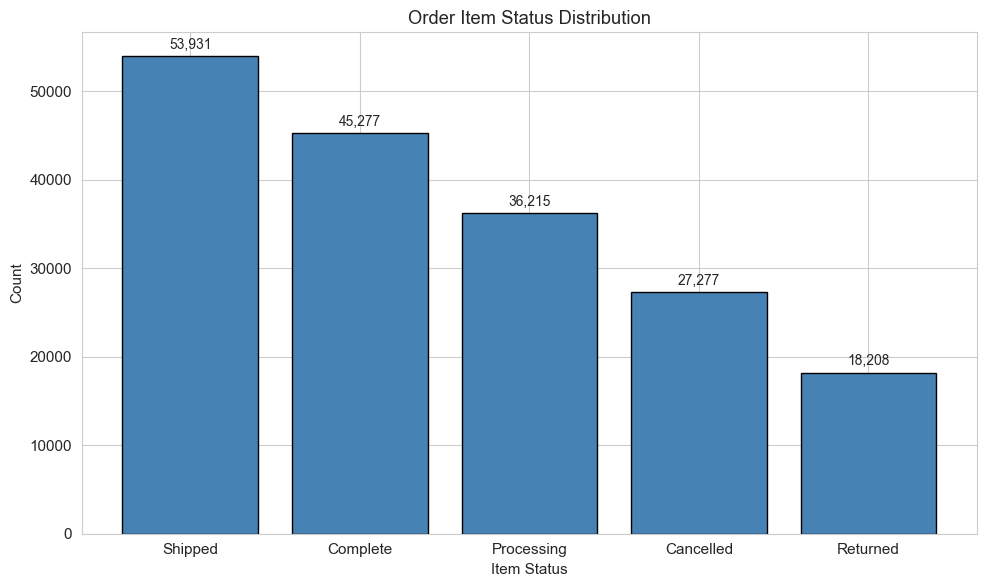

In [12]:
# Visualize status distribution
fig = plot_status_distribution(df)
plt.show()

## EDA: Return Rate Analysis

In [13]:
# Return rate by category and brand using modeling module
ret_by_cat_brand = calculate_return_rates_by_group(
    df, 
    group_cols=["category", "brand"], 
    min_rows=200
)
ret_by_cat_brand.head(25)

,,item_rows,returned_items,return_rate
category,brand,,,
Shorts,American Apparel,204,31,0.151961
Tops & Tees,Harley-Davidson,207,31,0.149758
Active,ExOfficio,217,32,0.147465
Pants,Orvis,217,32,0.147465
Maternity,Three Seasons Maternity,253,36,0.142292
Shorts,O'Neill,239,32,0.133891
Suits & Sport Coats,Allegra K,347,46,0.132565
Maternity,A Pea in the Pod,234,31,0.132479
Socks,Hanes,210,27,0.128571


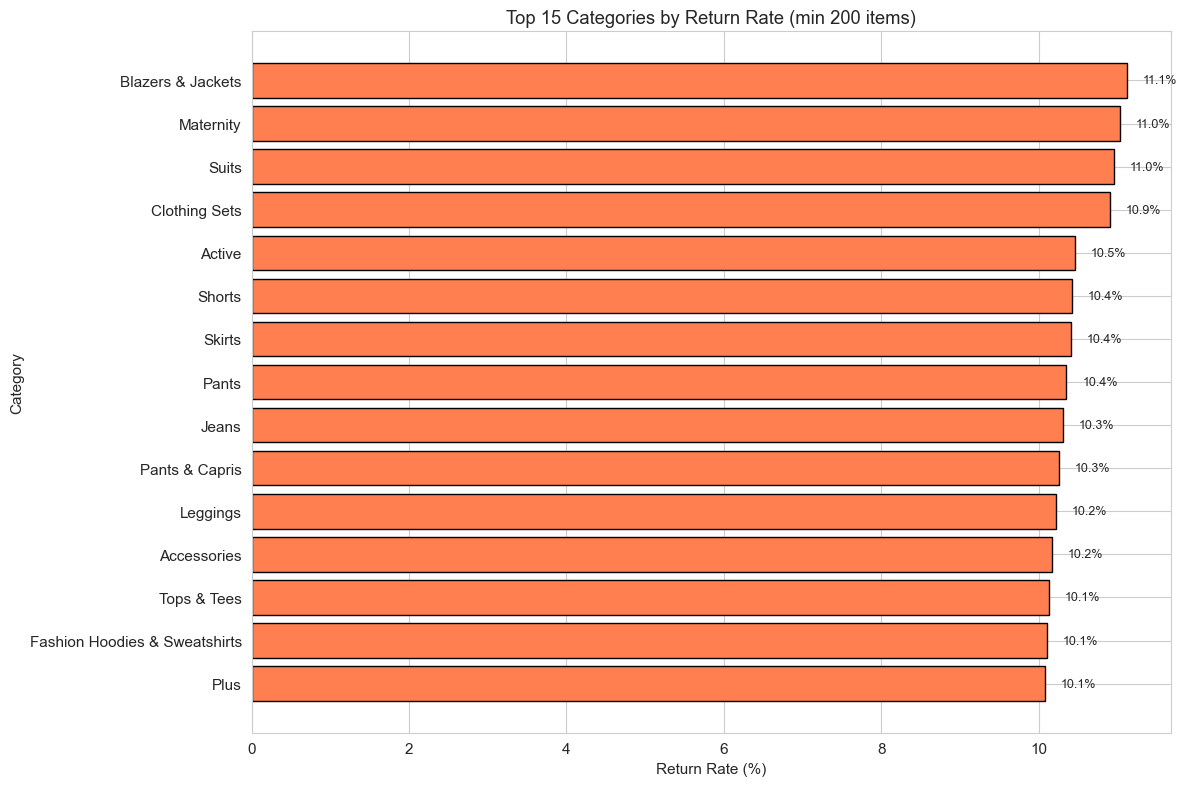

In [14]:
# Visualize return rates by category
fig = plot_return_rate_by_category(df, top_n=15, min_rows=200)
plt.show()

In [15]:
# Return rate by traffic source, country, and gender
ret_by_acq_geo = calculate_return_rates_by_group(
    df, 
    group_cols=["traffic_source", "country", "user_gender"], 
    min_rows=200
)
ret_by_acq_geo.head(25)

,,,item_rows,returned_items,return_rate
traffic_source,country,user_gender,,,
Facebook,United Kingdom,F,240,33,0.137500
Organic,Germany,F,511,67,0.131115
Display,United Kingdom,M,207,27,0.130435
Facebook,Germany,M,243,31,0.127572
Email,United States,M,1123,143,0.127337
Organic,United Kingdom,F,589,73,0.123939
Facebook,South Korea,M,277,34,0.122744
Organic,Australia,M,280,34,0.121429
Facebook,United States,M,1131,137,0.121132


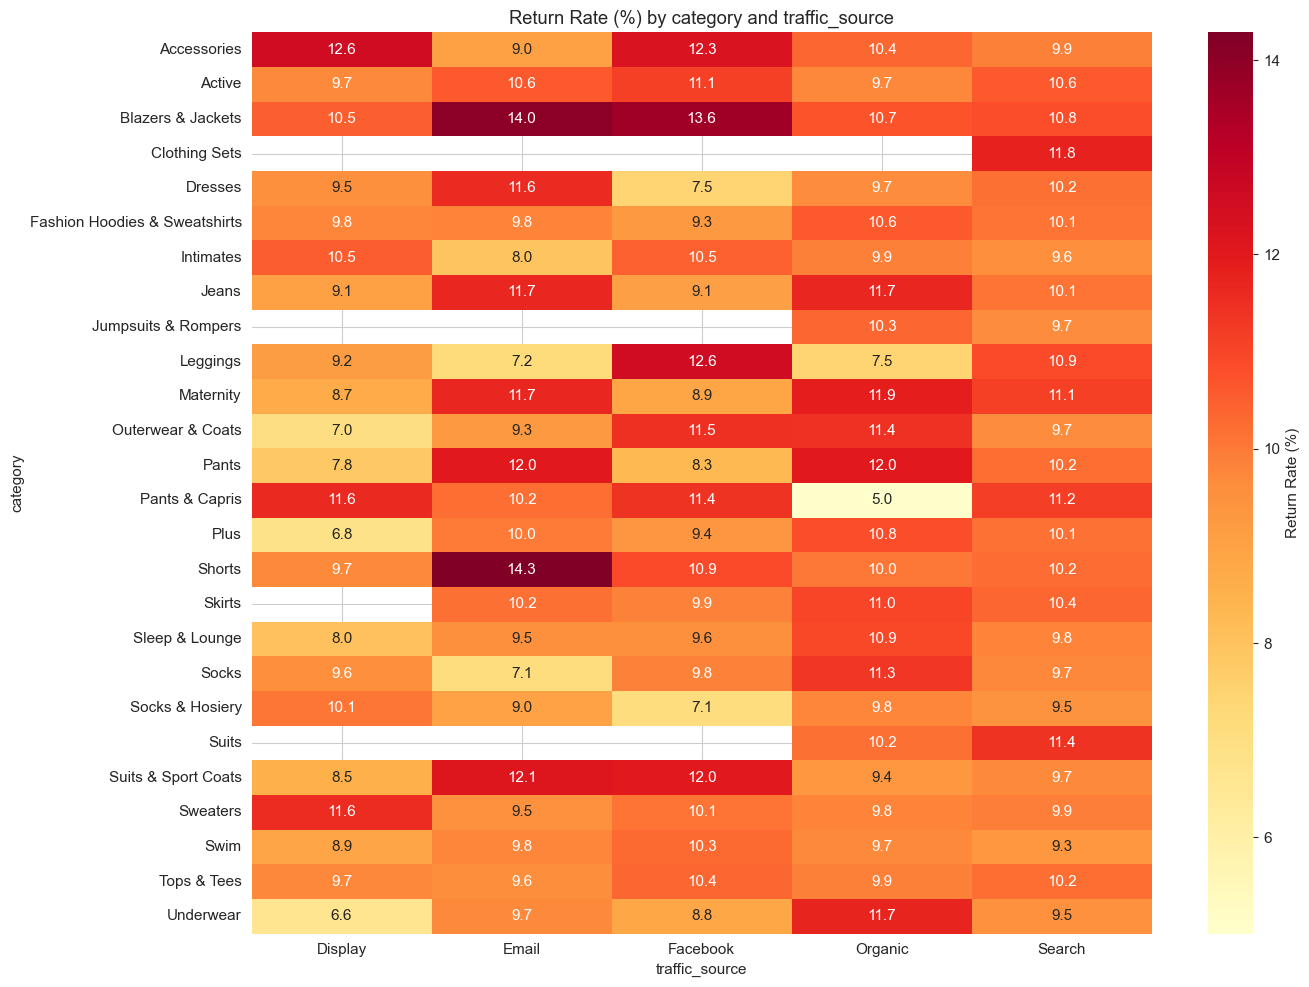

In [16]:
# Return rate heatmap: Category vs Traffic Source
fig = plot_return_rate_heatmap(
    df, 
    row_col="category", 
    col_col="traffic_source", 
    min_rows=100
)
plt.show()

## Margin-Focused EDA (Pre-Process Costs)

### Theme 1: Margin Exposure per Return Event

**Key Questions:**
1. What is the distribution of margin dollars on returned items?
2. Are returns predominantly low-margin or high-margin exposures?
3. How fat is the upper tail (large margin reversals)?

In [17]:
# Margin distribution for returned items
returned_margin = df.loc[df["is_returned_item"] == 1, "item_margin"]
returned_margin.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

count    18208.000000
mean        30.991572
std         36.232896
min          0.312620
10%          6.964300
25%         11.775000
50%         20.515156
75%         36.288000
90%         66.182473
99%        166.860750
max        535.478999
Name: item_margin, dtype: float64

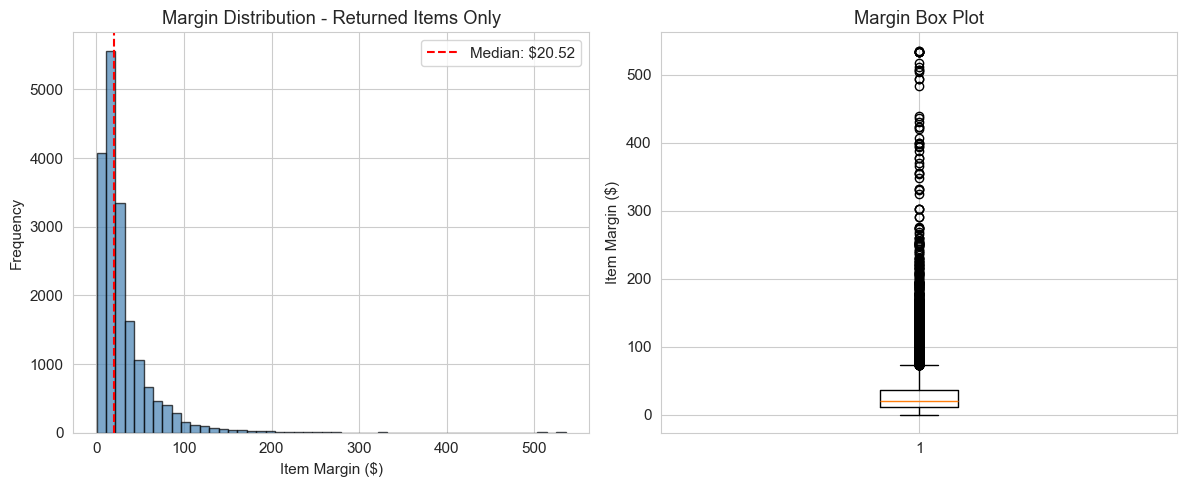

In [18]:
# Visualize margin distribution for returned items
fig = plot_margin_distribution(df, returned_only=True)
plt.show()

### Theme 2: Lost Sales Value on Returned Items

Here, lost sales means reversed revenue, not opportunity cost.

**This answers:**
- Are returns economically concentrated?
- Do a small number of returns drive disproportionate revenue reversals?

In [19]:
# Sales distribution for returned items
returned_sales = df.loc[df["is_returned_item"] == 1, "sale_price"]
returned_sales.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])

count    18208.000000
mean        59.709403
std         65.476488
min          0.490000
10%         13.990000
25%         24.772501
50%         40.000000
75%         69.989998
90%        128.000000
99%        299.000000
max        999.000000
Name: sale_price, dtype: float64

### Theme 3: Margin Loss by Product Context

**Questions:**
- Which categories account for the largest absolute margin loss?
- Do some categories combine high margin per item with returns?

In [20]:
# Margin loss by category using modeling module
margin_loss_by_category = calculate_margin_loss_by_group(df, group_cols=["category"])
margin_loss_by_category.head(15)

,returned_items,total_lost_sales,total_lost_margin,median_margin_per_return,avg_margin_per_return
category,,,,,
Outerwear & Coats,931,137944.849823,76693.733705,60.496000,82.377802
Jeans,1286,123909.350129,57359.967938,35.875174,44.603397
Sweaters,1109,85196.299951,44052.767296,31.107509,39.722964
Suits & Sport Coats,492,61166.229997,36525.572048,56.794319,74.238968
Fashion Hoodies & Sweatshirts,1192,64985.290035,31203.595301,23.518600,26.177513
Sleep & Lounge,1094,57169.620177,29629.574551,19.971220,27.083706
Swim,1069,60293.780057,29523.019460,22.535309,27.617418
Active,947,46321.120052,26747.333446,19.437000,28.244280
Accessories,996,43717.559963,26296.765952,15.035990,26.402375


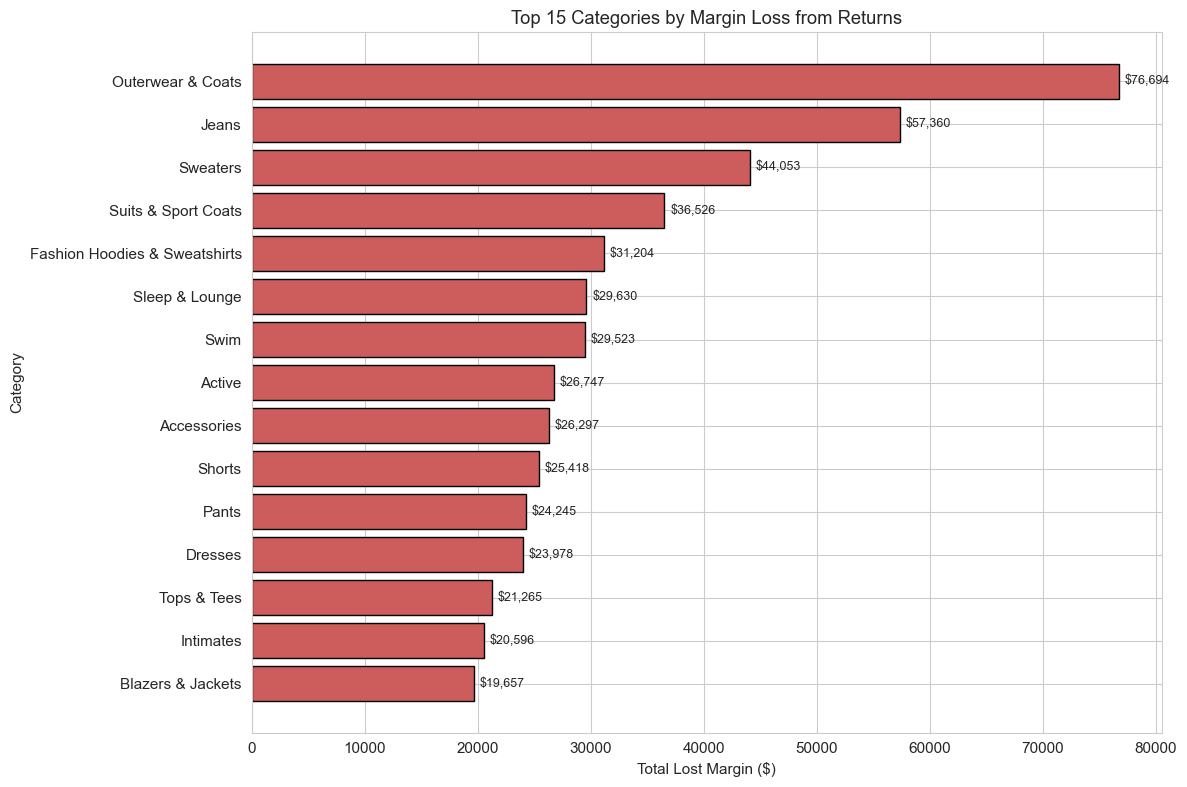

In [21]:
# Visualize margin loss by category
fig = plot_margin_loss_by_category(df, top_n=15)
plt.show()

### Theme 4: Customer-Level Margin Exposure from Returns

**Questions:**
- Are margin losses dispersed or concentrated among customers?
- Do some customers generate high cumulative margin reversals?

In [24]:
# Customer margin exposure using modeling module
customer_exposure = calculate_customer_margin_exposure(df)
customer_exposure.head(20)

,return_events,total_lost_margin,total_lost_sales,median_margin_per_return,max_single_return_margin
user_id,,,,,
46358,5,660.286698,1230.989998,36.476199,507.485999
73088,4,601.724230,1030.820002,29.405225,535.478999
9592,2,560.598027,991.769997,280.299013,503.873999
73720,2,555.082019,945.990002,277.541010,533.672998
48158,2,545.759348,925.990000,272.879674,532.769998
34216,1,535.478999,903.000000,535.478999,535.478999
79918,2,534.529997,1040.000000,267.264999,511.829997
7008,1,533.672998,903.000000,533.672998,533.672998
82057,1,532.769998,903.000000,532.769998,532.769998


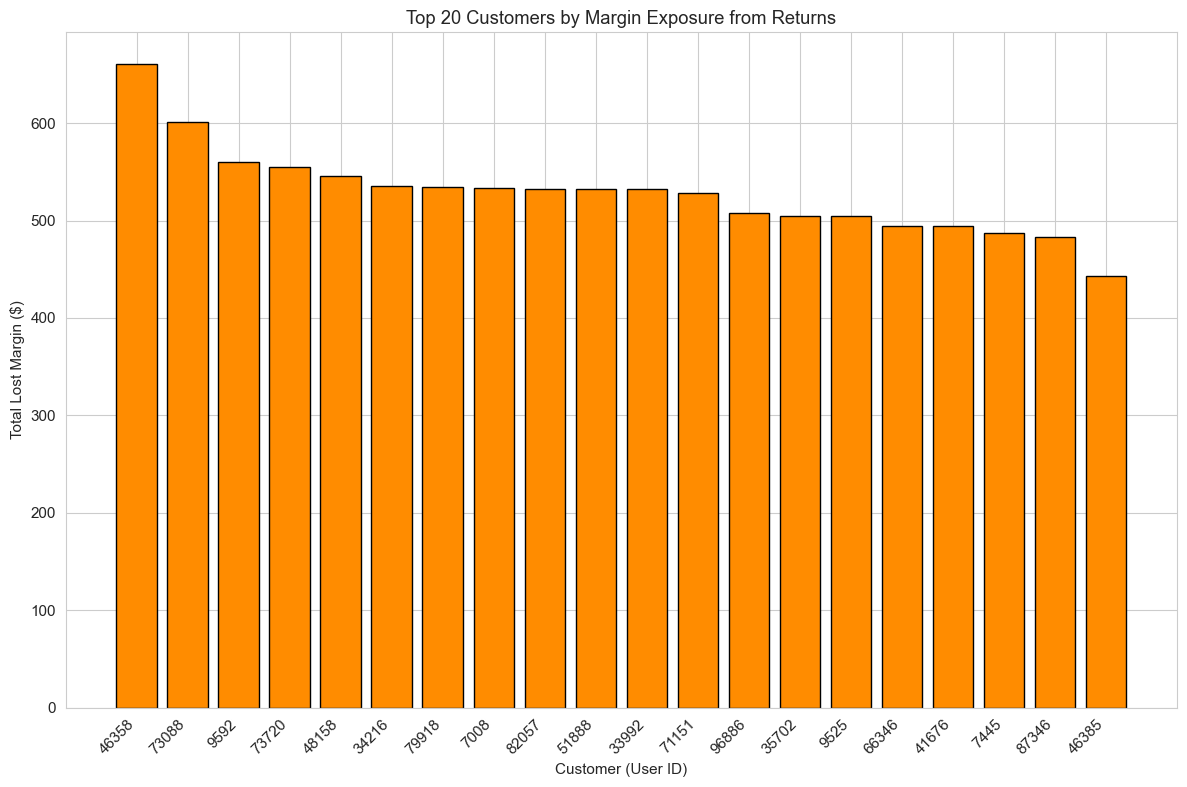

In [27]:
# Visualize customer margin exposure
fig = plot_customer_margin_exposure(df, top_n=20)
plt.show()


## Profit Erosion Summary

This section combines margin reversal with estimated return processing costs to calculate total profit erosion.

In [28]:
# Generate profit erosion summary
erosion_summary = summarize_profit_erosion(df, cost_per_return=15.0)

print("=" * 50)
print("PROFIT EROSION SUMMARY")
print("=" * 50)
print(f"Total items analyzed: {erosion_summary['total_items']:,}")
print(f"Total returned items: {erosion_summary['total_returned']:,}")
print(f"Return rate: {erosion_summary['return_rate_pct']:.2f}%")
print()
print(f"Total margin reversal: ${erosion_summary['total_margin_reversal']:,.2f}")
print(f"Avg margin per return: ${erosion_summary['avg_margin_per_return']:.2f}")
print(f"Median margin per return: ${erosion_summary['median_margin_per_return']:.2f}")
print(f"Max single margin loss: ${erosion_summary['max_single_margin_loss']:.2f}")
print()
print(f"Estimated process costs (@$15/return): ${erosion_summary['estimated_process_costs']:,.2f}")
print(f"TOTAL PROFIT EROSION: ${erosion_summary['total_profit_erosion']:,.2f}")
print()
print(f"% of total margin lost to returns: {erosion_summary['pct_margin_lost_to_returns']:.2f}%")
print("=" * 50)

PROFIT EROSION SUMMARY
Total items analyzed: 180,908
Total returned items: 18,208
Return rate: 10.06%

Total margin reversal: $564,294.54
Avg margin per return: $30.99
Median margin per return: $20.52
Max single margin loss: $535.48

Estimated process costs (@$15/return): $273,120.00
TOTAL PROFIT EROSION: $837,414.54

% of total margin lost to returns: 10.05%


## Customer Segmentation by Return Behavior

In [29]:
# Segment customers by return behavior
customer_segments = segment_customers_by_return_behavior(
    df, 
    return_rate_thresholds=(0.05, 0.15)
)

# Segment distribution
segment_counts = customer_segments["return_segment"].value_counts()
print("Customer Segment Distribution:")
print(segment_counts)
print()
print(f"Total customers: {len(customer_segments):,}")

Customer Segment Distribution:
return_segment
no_returns           67956
high_returner        11718
moderate_returner      270
Name: count, dtype: int64

Total customers: 79,944


In [30]:
# Analyze segments
segment_summary = (
    customer_segments
    .groupby("return_segment")
    .agg(
        customer_count=("total_items", "count"),
        avg_items=("total_items", "mean"),
        avg_returns=("return_events", "mean"),
        avg_return_rate=("return_rate", "mean"),
        total_margin=("total_margin", "sum"),
    )
    .round(2)
)
segment_summary

,customer_count,avg_items,avg_returns,avg_return_rate,total_margin
return_segment,,,,,
high_returner,11718,2.76,1.53,0.68,998687.15
moderate_returner,270,7.54,1.00,0.13,62615.91
no_returns,67956,2.16,0.00,0.00,4554085.07


## Customer Behavioral Profile

In [31]:
# Build customer behavior profile using modeling module
customer_behavior = build_customer_behavior_profile(df)
customer_behavior.describe()

,total_items,total_orders,return_events,total_sales,total_margin,avg_item_price,avg_item_margin,avg_discount_pct,delivered_items,return_rate,items_per_order
count,79944.000000,79944.000000,79944.000000,79944.000000,79944.000000,79944.000000,79944.000000,79944.0,79944.000000,79944.000000,79944.000000
mean,2.262934,1.562381,0.227759,135.255333,70.241521,59.951178,31.157664,0.0,0.773817,0.100789,1.449275
std,1.600215,0.859629,0.643842,138.479309,74.077067,54.003167,29.776293,0.0,1.129507,0.269227,0.716939
min,1.000000,1.000000,0.000000,0.490000,0.312620,0.490000,0.312620,0.0,0.000000,0.000000,1.000000
25%,1.000000,1.000000,0.000000,42.000000,21.076000,29.990000,15.000000,0.0,0.000000,0.000000,1.000000
50%,2.000000,1.000000,0.000000,89.500000,45.737684,46.975000,23.588643,0.0,0.000000,0.000000,1.000000
75%,3.000000,2.000000,0.000000,182.490000,94.136147,71.970000,37.288034,0.0,1.000000,0.000000,2.000000
max,13.000000,4.000000,8.000000,1733.430000,981.555083,999.000000,568.099998,0.0,10.000000,1.000000,4.000000


## Data Limitations

**Note on Return Timing Data:**

The `returned_at` timestamp columns in the TheLook dataset are sparsely populated, which prevents return latency analysis. This is a known limitation and reinforces our methodological focus on economic exposure rather than return timing patterns.

In [32]:
# Check return timestamp availability
return_timestamp_coverage = df[[
    "item_returned_at",
    "order_returned_at",
    "item_delivered_at",
    "order_delivered_at"
]].notna().mean() * 100

print("Return/Delivery Timestamp Coverage (% non-null):")
print(return_timestamp_coverage.round(2))

Return/Delivery Timestamp Coverage (% non-null):
item_returned_at       0.24
order_returned_at      0.24
item_delivered_at     34.20
order_delivered_at    34.20
dtype: float64
